In [1]:
# ============================================================================
# STEP 1: SETUP - IMPORTS AND CONFIGURATION
# ============================================================================

import os
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import json
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)
print("Student: Sanjay Chaudhary (B01036144)")
print("=" * 70)

# Check hardware
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("\nUsing Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("\nUsing CUDA GPU")
else:
    device = torch.device('cpu')
    print("\nUsing CPU")

print(f"Device: {device}")

# Configuration
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 5
DATA_DIR = "../datasets/aptos_2019/images"

# Class names in ICDRSS order
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

print(f"\nClass Names (ICDRSS Standard):")
for i, name in enumerate(class_names):
    print(f"  Class {i}: {name}")

MODEL EVALUATION
Student: Sanjay Chaudhary (B01036144)

Using Apple MPS GPU
Device: mps

Class Names (ICDRSS Standard):
  Class 0: No DR
  Class 1: Mild
  Class 2: Moderate
  Class 3: Severe
  Class 4: Proliferative


In [3]:
# ============================================================================
# STEP 2: DEFINE FIXED DATASET CLASS
# ============================================================================

class FixedAPTOSDataset(Dataset):
    """Fix class labels to ICDRSS standard"""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.folder_to_label = {
            'Mild': 1,
            'Moderate': 2,
            'No_DR': 0,
            'Proliferate_DR': 4,
            'Severe': 3
        }
        
        self.raw_dataset = datasets.ImageFolder(root=root_dir, transform=None)
        self.samples = []
        self.labels = []
        
        for img, wrong_label in self.raw_dataset:
            folder_name = self.raw_dataset.classes[wrong_label]
            correct_label = self.folder_to_label[folder_name]
            self.samples.append(img)
            self.labels.append(correct_label)
        
        print(f"Fixed dataset loaded: {len(self.samples)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img = self.samples[idx]
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [4]:
# ============================================================================
# STEP 3: DEFINE EVALUATION TRANSFORMS (NO AUGMENTATION)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: DEFINING TRANSFORMATIONS")
print("=" * 70)

# Use same transform as validation (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Evaluation transform (no augmentation):")
print("  - Resize to 224x224")
print("  - Convert to tensor")
print("  - Normalize with ImageNet statistics")


STEP 3: DEFINING TRANSFORMATIONS
Evaluation transform (no augmentation):
  - Resize to 224x224
  - Convert to tensor
  - Normalize with ImageNet statistics


In [5]:
# ============================================================================
# STEP 4: LOAD VALIDATION DATA
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: LOADING VALIDATION DATA")
print("=" * 70)

# Load split indices
split_data = torch.load('../models/split_indices.pt', weights_only=False)
val_idx = split_data['val_idx']
class_names = split_data['class_names']

print(f"Validation indices: {len(val_idx)}")

# Create validation dataset
val_dataset_full = FixedAPTOSDataset(root_dir=DATA_DIR, transform=eval_transform)
val_dataset = Subset(val_dataset_full, val_idx)

# Create data loader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Validation samples: {len(val_dataset)}")
print(f"Validation batches: {len(val_loader)}")


STEP 4: LOADING VALIDATION DATA
Validation indices: 733
Fixed dataset loaded: 3662 images
Validation samples: 733
Validation batches: 23


In [6]:
# ============================================================================
# STEP 5: LOAD TRAINED MODEL
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: LOADING TRAINED MODEL")
print("=" * 70)

class DRResNet50(nn.Module):
    """ResNet50 adapted for diabetic retinopathy detection"""
    
    def __init__(self, num_classes=5):
        super(DRResNet50, self).__init__()
        self.model = models.resnet50(weights=None)
        num_features = self.model.fc.in_features
        self.model.fc = nn.Linear(num_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

# Create model
model = DRResNet50(num_classes=NUM_CLASSES)
model = model.to(device)

# Load best model
if os.path.exists('../models/best_model.pth'):
    checkpoint = torch.load('../models/best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
    print(f"  Validation loss: {checkpoint['val_loss']:.4f}")
elif os.path.exists('../models/best_model_stage1.pth'):
    model.load_state_dict(torch.load('../models/best_model_stage1.pth', map_location=device))
    print("Loaded Stage 1 model (best_model_stage1.pth)")
else:
    print("WARNING: No trained model found!")
    print("Please run Notebook 03 first to train the model.")

model.eval()


STEP 5: LOADING TRAINED MODEL
Loaded best model from epoch 15
  Validation accuracy: 80.49%
  Validation loss: 1.1256


DRResNet50(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
         

In [7]:
# ============================================================================
# STEP 6: EVALUATE MODEL ON VALIDATION DATA
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: EVALUATING MODEL")
print("=" * 70)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"\nOverall Metrics:")
print("-" * 40)
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Per-class metrics
print(f"\nPer-Class Metrics:")
print("-" * 60)
print(f"{'Class':15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 60)

for i, name in enumerate(class_names):
    class_indices = np.where(all_labels == i)[0]
    if len(class_indices) > 0:
        preds_for_class = all_preds[class_indices]
        precision_class = precision_score(all_labels[class_indices], preds_for_class, average='weighted', zero_division=0)
        recall_class = recall_score(all_labels[class_indices], preds_for_class, average='weighted', zero_division=0)
        f1_class = f1_score(all_labels[class_indices], preds_for_class, average='weighted', zero_division=0)
        support = len(class_indices)
        
        print(f"{name:15} {precision_class:10.4f} {recall_class:10.4f} {f1_class:10.4f} {support:10d}")

print("-" * 60)


STEP 6: EVALUATING MODEL

Overall Metrics:
----------------------------------------
  Accuracy:  0.8049 (80.49%)
  Precision: 0.8106
  Recall:    0.8049
  F1-Score:  0.8060

Per-Class Metrics:
------------------------------------------------------------
Class            Precision     Recall   F1-Score    Support
------------------------------------------------------------
No DR               1.0000     0.9557     0.9773        361
Mild                1.0000     0.7162     0.8346         74
Moderate            1.0000     0.7300     0.8439        200
Severe              1.0000     0.3590     0.5283         39
Proliferative       1.0000     0.5424     0.7033         59
------------------------------------------------------------



STEP 7: CONFUSION MATRIX

Confusion Matrix (Rows = True, Columns = Predicted):
----------------------------------------------------------------------
                 No DR      Mild  Moderate    Severe  Prolifer
----------------------------------------------------------------------
No DR              345        13         3         0         0
Mild                 7        53        12         0         2
Moderate             6        22       146        15        11
Severe               0         3        10        14        12
Proliferative         0         8        15         4        32


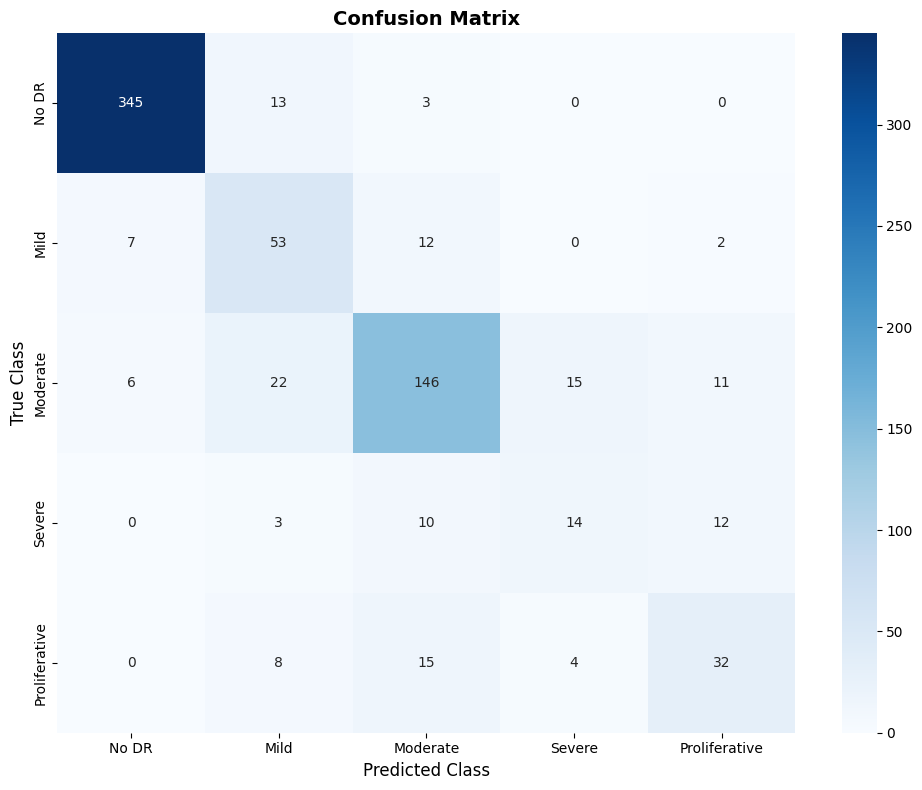


Saved: results/figures/confusion_matrix.png


In [8]:
# ============================================================================
# STEP 7: CONFUSION MATRIX
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: CONFUSION MATRIX")
print("=" * 70)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix (Rows = True, Columns = Predicted):")
print("-" * 70)
print(f"{'':12}", end="")
for name in class_names:
    print(f"{name[:8]:>10}", end="")
print()
print("-" * 70)

for i, name in enumerate(class_names):
    print(f"{name:12}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i, j]:>10}", end="")
    print()

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()

# Save figure
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: results/figures/confusion_matrix.png")

In [9]:
# ============================================================================
# STEP 8: CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: CLASSIFICATION REPORT")
print("=" * 70)

print("\n" + classification_report(all_labels, all_preds, target_names=class_names))


STEP 8: CLASSIFICATION REPORT

               precision    recall  f1-score   support

        No DR       0.96      0.96      0.96       361
         Mild       0.54      0.72      0.61        74
     Moderate       0.78      0.73      0.76       200
       Severe       0.42      0.36      0.39        39
Proliferative       0.56      0.54      0.55        59

     accuracy                           0.80       733
    macro avg       0.65      0.66      0.65       733
 weighted avg       0.81      0.80      0.81       733



In [10]:
# ============================================================================
# STEP 9: CONFIDENCE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: CONFIDENCE ANALYSIS")
print("=" * 70)

# Get predicted class and confidence
predicted_classes = all_preds
confidences = np.max(all_probs, axis=1)

# Average confidence per class
print("\nAverage Confidence per Class:")
print("-" * 50)
for i, name in enumerate(class_names):
    class_confidences = confidences[all_labels == i]
    if len(class_confidences) > 0:
        avg_conf = np.mean(class_confidences)
        print(f"  {name:15}: {avg_conf:.4f} ({avg_conf*100:.1f}%)")

# Correct vs incorrect confidence
correct_mask = (all_preds == all_labels)
incorrect_mask = ~correct_mask

correct_conf = np.mean(confidences[correct_mask]) if np.any(correct_mask) else 0
incorrect_conf = np.mean(confidences[incorrect_mask]) if np.any(incorrect_mask) else 0

print(f"\nConfidence Analysis:")
print("-" * 50)
print(f"  Correct predictions average confidence: {correct_conf:.4f} ({correct_conf*100:.1f}%)")
print(f"  Incorrect predictions average confidence: {incorrect_conf:.4f} ({incorrect_conf*100:.1f}%)")


STEP 9: CONFIDENCE ANALYSIS

Average Confidence per Class:
--------------------------------------------------
  No DR          : 0.9717 (97.2%)
  Mild           : 0.7973 (79.7%)
  Moderate       : 0.7666 (76.7%)
  Severe         : 0.7931 (79.3%)
  Proliferative  : 0.7976 (79.8%)

Confidence Analysis:
--------------------------------------------------
  Correct predictions average confidence: 0.9060 (90.6%)
  Incorrect predictions average confidence: 0.7450 (74.5%)


In [11]:
# ============================================================================
# STEP 10: SAVE EVALUATION RESULTS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 10: SAVING EVALUATION RESULTS")
print("=" * 70)

# Prepare results dictionary
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

evaluation_results = {
    'overall_metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    },
    'per_class_metrics': {
        class_names[i]: {
            'precision': float(report[class_names[i]]['precision']),
            'recall': float(report[class_names[i]]['recall']),
            'f1_score': float(report[class_names[i]]['f1-score']),
            'support': int(report[class_names[i]]['support'])
        } for i in range(len(class_names))
    },
    'confusion_matrix': cm.tolist(),
    'confidence_analysis': {
        'correct_predictions_avg_confidence': float(correct_conf),
        'incorrect_predictions_avg_confidence': float(incorrect_conf)
    }
}

# Save to JSON
with open('../results/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print("Saved: results/evaluation_results.json")


STEP 10: SAVING EVALUATION RESULTS
Saved: results/evaluation_results.json


In [12]:
# ============================================================================
# STEP 11: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("NOTEBOOK 04 COMPLETE")
print("=" * 70)

print("\nWHAT I ACCOMPLISHED:")
print("-" * 60)
print(f"1. Loaded validation dataset: {len(val_dataset)} images")
print(f"2. Loaded trained model from Notebook 03")
print(f"3. Evaluated model on validation data")
print(f"   - Overall Accuracy: {accuracy*100:.2f}%")
print(f"   - Weighted F1-Score: {f1:.4f}")
print(f"4. Generated confusion matrix")
print(f"5. Created classification report")
print(f"6. Analyzed model confidence")
print(f"7. Saved evaluation results to JSON")

print("\nFILES SAVED:")
print("-" * 60)
print("  - results/figures/confusion_matrix.png")
print("  - results/evaluation_results.json")

print("\n" + "=" * 70)
print("NEXT: Open Notebook 05 - Grad-CAM Explainability")
print("=" * 70)


NOTEBOOK 04 COMPLETE

WHAT I ACCOMPLISHED:
------------------------------------------------------------
1. Loaded validation dataset: 733 images
2. Loaded trained model from Notebook 03
3. Evaluated model on validation data
   - Overall Accuracy: 80.49%
   - Weighted F1-Score: 0.8060
4. Generated confusion matrix
5. Created classification report
6. Analyzed model confidence
7. Saved evaluation results to JSON

FILES SAVED:
------------------------------------------------------------
  - results/figures/confusion_matrix.png
  - results/evaluation_results.json

NEXT: Open Notebook 05 - Grad-CAM Explainability
